**Laboratory Task 4**

Instruction: Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [3]:
#random seed for reproducibility
torch.manual_seed(42)

# input data
X = torch.linspace(0, 10, 200).reshape(-1, 1)

# target values
y = 3 * X + 5 + torch.randn_like(X) * 2

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([200, 1])
y shape: torch.Size([200, 1])


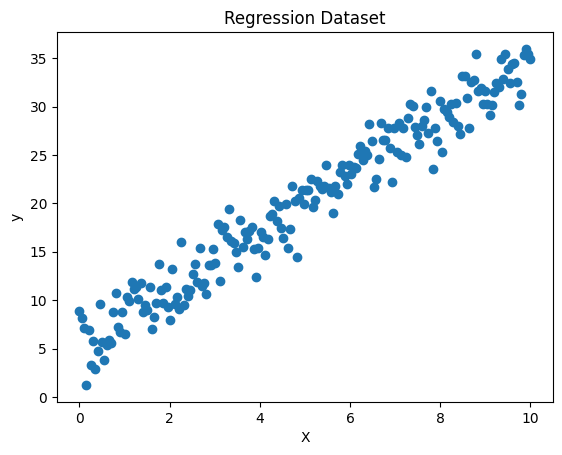

In [4]:
plt.scatter(X.numpy(), y.numpy())
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Dataset")
plt.show()

In [5]:
dataset = TensorDataset(X, y)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [6]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [7]:
model = RegressionModel()

print(model)

RegressionModel(
  (fc1): Linear(in_features=1, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [8]:
criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

Epoch [100/1000], Loss: 4.0099
Epoch [200/1000], Loss: 4.1487
Epoch [300/1000], Loss: 3.9409
Epoch [400/1000], Loss: 3.9704
Epoch [500/1000], Loss: 4.0260
Epoch [600/1000], Loss: 3.9723
Epoch [700/1000], Loss: 3.9443
Epoch [800/1000], Loss: 4.0331
Epoch [900/1000], Loss: 3.9687
Epoch [1000/1000], Loss: 4.0568


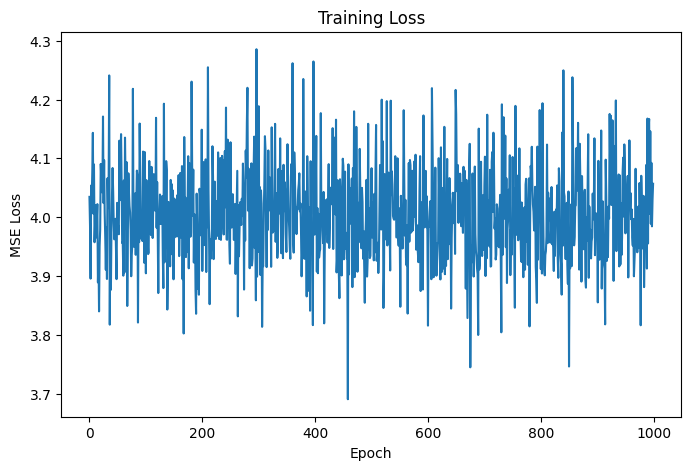

In [11]:
epochs = 1000

loss_history = []

for epoch in range(epochs):

    epoch_loss = 0

    for X_batch, y_batch in dataloader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(dataloader)
    loss_history.append(average_loss)

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {average_loss:.4f}"
        )

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.show()

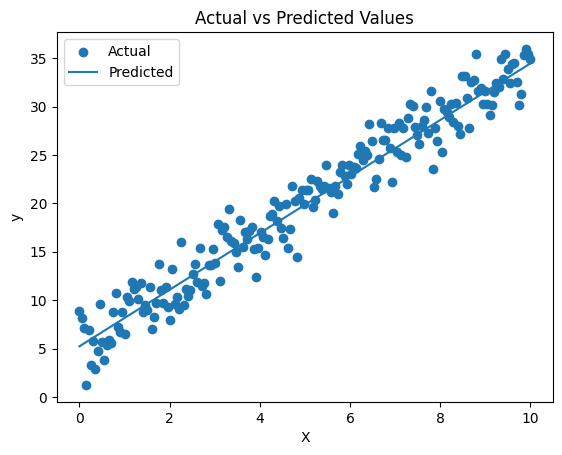

In [12]:
model.eval()

with torch.no_grad():
    predictions = model(X)

plt.scatter(X.numpy(), y.numpy(), label="Actual")
plt.plot(X.numpy(), predictions.numpy(), label="Predicted")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

**Conclusion**

The linear regression model was successfully implemented and trained using PyTorch. The model used two fully connected layers, MSE Loss as the criterion, a batch size of 8, SGD optimizer, and 1000 epochs. After adjusting the learning rate to ensure stable training, the model was able to learn the relationship between the input and target values, as shown by the decreasing training loss. This laboratory activity demonstrated how a neural network can be trained for a regression problem using PyTorch.